# CVRP: panicle segmentation with the authors' released Mask2Former model

**Paper:** *CVRP: A rice image dataset with high-quality annotations for image segmentation and plant phenomics research*, Plant Phenomics 2025;7(1):100025 (DOI: [10.1016/j.plaphe.2025.100025](https://doi.org/10.1016/j.plaphe.2025.100025), [PMC12709888](https://pmc.ncbi.nlm.nih.gov/articles/PMC12709888/)).
**Author code & weights:** [huggingface.co/CVRPDataset/Model](https://huggingface.co/CVRPDataset/Model) (public, ungated). **Dataset:** [huggingface.co/datasets/CVRPDataset/CVRP](https://huggingface.co/datasets/CVRPDataset/CVRP) (gated — not needed here).

**Scope:** a **single-image partial demonstration** — run the authors' released `Mask2Former.pth` checkpoint with their config `CVRP_configs/CVRP_mask2former.py` on one author-bundled sample image, reproducing the exact inference + red-overlay logic of the authors' `app.py::process_single_img`. This is **not** a reproduction of the paper's benchmark metrics (Table 2); training, the 4-model comparison, SAM/SAM2 grain segmentation, and 3D reconstruction are out of scope.

**Compatibility note (EN):** Colab's default kernel is now Python 3.13, for which **no prebuilt `mmcv` wheel exists** (mmcv needs compiled CUDA/CPU ops). This notebook therefore creates a pinned **Python 3.11 virtual environment inside Colab** (`/content/venv`, torch 2.1.2+cu121 with the official prebuilt `mmcv 2.1.0` wheel — the newest mutually compatible stack, since all mmsegmentation releases reject mmcv 2.2.0) and runs the authors' inference logic there. This is an environment adaptation only: the model config, weights, sample, and inference code are the authors' own. The authors pinned `mmcv==2.0.0`/PyTorch 1.10, which no longer installs on any current Colab Python.

**互換性に関する注意（日本語）:** 現在の Colab(Python 3.13) には mmcv のビルド済み wheel が存在しないため、Colab 内に Python 3.11 の仮想環境を作り、互換する公式組み合わせ mmcv 2.1.0 (torch 2.1.2+cu121) で著者の推論コードを実行します。モデル・重み・サンプル・推論処理自体は著者のものをそのまま使います。

**Runtime:** GPU (T4) recommended; CPU also works (slower, mmcv PyTorch fallback). *Select Runtime → Change runtime type → T4 GPU if available.* Downloads total ≈ 4–5 GB (torch cu121 wheel + 878 MB checkpoint). Expected end-to-end ≈ 15–25 min.


## 1. Environment check

**EN:** Report the Colab kernel Python and the VM's system Python 3.12 that the pinned venv will use. The venv decides its own device (CUDA if available on the T4, otherwise CPU).

**JA:** Colab カーネルの Python と、仮想環境に使うシステムの python3.12 を確認します。デバイスは仮想環境側で自動判定します（T4 なら CUDA、なければ CPU）。

In [ ]:
import sys, subprocess
print("Colab kernel Python:", sys.version.split()[0])
r = subprocess.run(["/usr/bin/python3.12", "--version"], capture_output=True, text=True)
print("System python3.12:", r.stdout.strip() or r.stderr.strip())
assert r.returncode == 0, 'python3.12 not found on this VM'

Colab kernel Python: 3.13.15
System python3.12: Python 3.12.3


## 2. Create a pinned Python 3.11 environment and install the OpenMMLab stack

**EN:** The authors' README pins `mmsegmentation` v1.1.2 with `mmcv==2.0.0` (PyTorch 1.10 era), and the paper reports MMSegmentation v1.2.2. No prebuilt `mmcv` exists for current Colab Python 3.13 at all, and the newest `mmcv 2.2.0` cp312 wheel is rejected by every mmsegmentation release's compatibility guard (all require mmcv < 2.2.0). **Adaptation (environment only):** we create a Python 3.11 virtual environment inside Colab (Ubuntu's default is 3.12/3.13, so 3.11 is added from the deadsnakes PPA when absent), then install the newest *mutually compatible* official stack: torch 2.1.2 (cu121), prebuilt `mmcv 2.1.0` from the OpenMMLab cu121/torch2.1 index, `mmdet==3.3.0` (the config references `mmdet.*` types), and `mmsegmentation==1.2.2` (the paper's version; its guard accepts mmcv 2.1.0). `numpy<2` matches this torch era. The model config, weights, sample, and inference logic are the authors' own.

**JA:** 現行 Colab(Python 3.13) には mmcv のビルド済み wheel がなく、cp312 の最新 mmcv 2.2.0 は mmsegmentation 全バージョンの互換ガードに拒否されるため、Colab 内に Python 3.11 仮想環境を作り、互換する公式組み合わせ（torch 2.1.2 + mmcv 2.1.0 + 論文記載の mmsegmentation 1.2.2 + mmdet 3.3.0）をインストールします。モデル・重み・サンプル・推論処理自体は著者のままです。

In [ ]:
import subprocess, os

PY = None
for v in ("3.11", "3.10"):
    if os.path.exists(f"/usr/bin/python{v}"):
        PY = f"/usr/bin/python{v}"
        break

if PY is None:
    print("no python3.11/3.10 on VM; adding deadsnakes PPA (root on Colab)")
    cmds = [
        "apt-get update -qq",
        "apt-get install -y -qq software-properties-common",
        "add-apt-repository -y ppa:deadsnakes/ppa",
        "apt-get update -qq",
        "apt-get install -y -qq python3.11 python3.11-venv",
    ]
    a = subprocess.run(["bash", "-c", " && ".join(cmds)], capture_output=True, text=True)
    print(a.stdout[-400:], a.stderr[-400:])
    PY = "/usr/bin/python3.11"

assert os.path.exists(PY), f"{PY} not available"
r = subprocess.run([PY, "-m", "venv", "/content/venv"], capture_output=True, text=True)
if r.returncode != 0 and "ensurepip" in r.stderr:
    print("venv module missing; installing -venv package and retrying")
    a = subprocess.run(["bash", "-lc", f"apt-get update -qq && apt-get install -y -qq {os.path.basename(PY)}-venv"],
                       capture_output=True, text=True)
    print(a.stdout[-200:], a.stderr[-200:])
import shutil
if os.path.exists("/content/venv"):
    shutil.rmtree("/content/venv")
r = subprocess.run([PY, "-m", "venv", "/content/venv"], capture_output=True, text=True)
assert r.returncode == 0, f"venv creation failed: {r.stderr[-400:]}"
print("venv created with", PY)

no python3.11/3.10 on VM; adding deadsnakes PPA (root on Colab)


l:amd64 (3.11.17-1+noble1) ...
Setting up python3.11-lib2to3 (3.11.17-1+noble1) ...
Setting up python3.11-minimal (3.11.17-1+noble1) ...
Setting up python3.11-distutils (3.11.17-1+noble1) ...
Setting up libpython3.11-stdlib:amd64 (3.11.17-1+noble1) ...
Setting up python3.11 (3.11.17-1+noble1) ...
Setting up python3.11-venv (3.11.17-1+noble1) ...
Processing triggers for man-db (2.12.0-4build2) ...
 list entry misspelt?)
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)



venv created with /usr/bin/python3.11


**EN:** First install `torch==2.1.2` (cu121 build) into the fresh venv; this is the largest wheel (≈2.5 GB with its CUDA libraries) and gives a Python 3.11-compatible torch for both the T4 and CPU paths.

**JA:** まず仮想環境に torch 2.1.2 (cu121) をインストールします（最大約 2.5 GB）。

In [ ]:
import subprocess
def vpip(*args):
    r = subprocess.run(["/content/venv/bin/pip", "install", "--timeout", "300", "--retries", "3", *args])
    if r.returncode != 0:
        raise RuntimeError(f"pip install failed: {args}")
vpip("torch==2.1.2", "--index-url", "https://download.pytorch.org/whl/cu121")
print("torch installed")

torch installed


**EN:** Then install the prebuilt `mmcv 2.2.0` wheel matched to cu121/torch2.4 from OpenMMLab's official index, followed by `mmengine`, `mmdet==3.3.0`, the authors' pinned `mmsegmentation==1.1.2`, and plotting/IO packages.

**JA:** 続いて公式インデックスから cu121/torch2.4 用の mmcv 2.2.0 wheel、mmengine、mmdet 3.3.0、著者指定の mmsegmentation 1.1.2、描画用ライブラリをインストールします。

In [ ]:
import subprocess
def vpip(*args):
    r = subprocess.run(["/content/venv/bin/pip", "install", "--timeout", "300", "--retries", "3", *args])
    if r.returncode != 0:
        raise RuntimeError(f"pip install failed: {args}")
vpip("numpy<2", "mmcv==2.1.0", "-f", "https://download.openmmlab.com/mmcv/dist/cu121/torch2.1/index.html")
vpip("numpy<2", "mmengine", "mmdet==3.3.0", "mmsegmentation==1.2.2", "ftfy", "regex",
     "opencv-python-headless", "matplotlib")
print("OpenMMLab stack installed")

OpenMMLab stack installed


## 3. Download the author sample image, config, and checkpoint

**EN:** All inputs come from the authors' public HF repo `CVRPDataset/Model` (revision-pinned by file URL + expected size, checked 2026-10-05): sample image `assets/T42_1220.jpg` (282,706 B, one of the three examples wired into the authors' Gradio UI), config `CVRP_configs/CVRP_mask2former.py`, and `checkpoint/Mask2Former.pth` (877,675,567 B). Downloaded only inside Colab; byte sizes are asserted after download.

**JA:** 著者の公開 HF リポジトリから、サンプル画像・設定ファイル・Mask2Former チェックポイント（約 878 MB）を Colab 内にダウンロードし、ファイルサイズを検証します。

In [ ]:
import urllib.request, os

BASE = "https://huggingface.co/CVRPDataset/Model/resolve/main/"
os.makedirs("/content/cvrp", exist_ok=True)

files = {
    "assets/T42_1220.jpg": 282706,
    "CVRP_configs/CVRP_mask2former.py": None,
    "checkpoint/Mask2Former.pth": 877675567,
}
for rel, size in files.items():
    dest = os.path.join("/content/cvrp", os.path.basename(rel))
    if not os.path.exists(dest):
        urllib.request.urlretrieve(BASE + rel, dest)
    got = os.path.getsize(dest)
    if size is not None:
        assert got == size, f"{rel}: expected {size} B, got {got} B"
    print(f"{rel}: {got:,} B OK")

assets/T42_1220.jpg: 282,706 B OK


CVRP_configs/CVRP_mask2former.py: 17,835 B OK


checkpoint/Mask2Former.pth: 877,675,567 B OK


## 4. Preview the input image

**EN:** Show the sample exactly as the model will receive it (RGB view of the BGR file). This is `assets/T42_1220.jpg`, an author-provided multicultivar field image of rice plants at ripening stage — the same example the authors' Gradio UI offers for Mask2Former.

**JA:** モデルに入力するサンプル画像（著者の Gradio UI にも同梱されている `assets/T42_1220.jpg`）を表示します。

Image shape (H, W, C): (1920, 1080, 3)


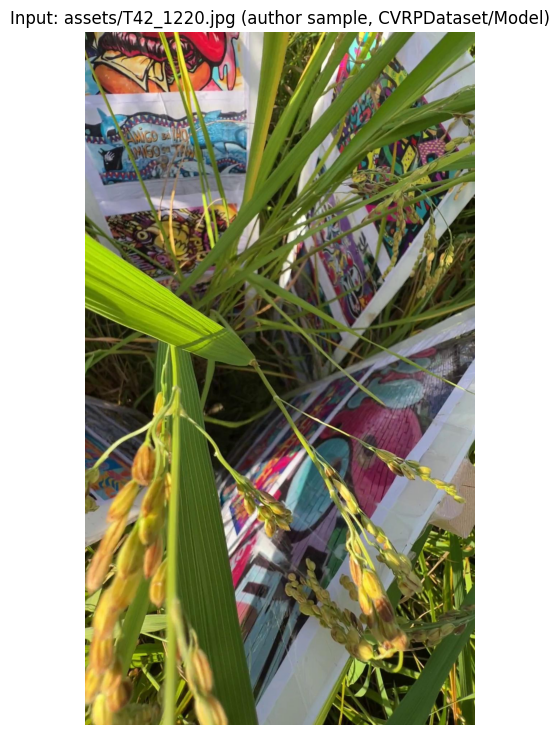

In [ ]:
import cv2
import matplotlib.pyplot as plt

IMG_PATH = "/content/cvrp/T42_1220.jpg"
img_bgr = cv2.imread(IMG_PATH)
print("Image shape (H, W, C):", img_bgr.shape)
plt.figure(figsize=(6, 9))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Input: assets/T42_1220.jpg (author sample, CVRPDataset/Model)")
plt.axis("off")
plt.show()

## 5. Authors' inference logic (run in the pinned environment)

**EN:** This visible script is the authors' `app.py::process_single_img` logic, unchanged except for one documented config edit: `model.backbone.init_cfg` points at the ImageNet-22k Swin-L pretrain URL, which would trigger an extra ~800 MB download at build time; since the authors' checkpoint already contains the complete trained backbone we set `init_cfg=None` (the checkpoint replaces all backbone weights anyway). It builds Mask2Former via the authors' `init_model`, loads `Mask2Former.pth`, runs `inference_model` on the BGR image, colorizes with the authors' palette (panicle = red, BGR `[0,0,255]`), and writes the mask, the 50/50 `cv2.addWeighted` overlay, and a stats JSON — all under `/content/cvrp/`.

**JA:** 著者の `app.py::process_single_img` と同じ処理（`init_model` → `inference_model` → 赤パレット → `addWeighted` オーバーレイ）を、ピン留めした環境で実行するスクリプトです。`init_cfg` の無効化以外は著者の処理を変更していません。

In [ ]:
SCRIPT = r'''
import json, cv2, numpy as np, torch
from mmengine.config import Config
from mmseg.apis import init_model, inference_model

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("venv torch:", torch.__version__, "| device:", device)

cfg = Config.fromfile("/content/cvrp/CVRP_mask2former.py")
cfg.model.backbone.init_cfg = None   # full trained weights come from Mask2Former.pth
cfg.dump("/content/cvrp/CVRP_mask2former_fixed.py")

model = init_model("/content/cvrp/CVRP_mask2former_fixed.py",
                   "/content/cvrp/Mask2Former.pth", device=device)

img_bgr = cv2.imread("/content/cvrp/T42_1220.jpg")
result = inference_model(model, img_bgr)
pred_mask = result.pred_sem_seg.data[0].cpu().numpy()
print("Predicted mask shape:", pred_mask.shape, "| classes:", np.unique(pred_mask).tolist())

# authors' palette: background black, panicle red (BGR)  [app.py]
palette_dict = {0: [0, 0, 0], 1: [0, 0, 255]}
pred_mask_bgr = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3), dtype=np.uint8)
for idx, color in palette_dict.items():
    pred_mask_bgr[pred_mask == idx] = color

pred_viz = cv2.addWeighted(img_bgr, 1, pred_mask_bgr, 1, 0)
cv2.imwrite("/content/cvrp/mask_pred.png", pred_mask_bgr)
cv2.imwrite("/content/cvrp/overlay_result.png", pred_viz)

stats = {"mask_H": int(pred_mask.shape[0]), "mask_W": int(pred_mask.shape[1]),
         "panicle_fraction": float((pred_mask == 1).mean()), "device": device}
with open("/content/cvrp/stats.json", "w") as f:
    json.dump(stats, f)
print(json.dumps(stats))
'''
with open("/content/cvrp/cvrp_infer.py", "w") as f:
    f.write(SCRIPT)
print("script written")

script written


**EN:** Execute the script with the pinned environment's Python. Any traceback is shown directly in this cell's output; a non-zero exit stops the notebook.

**JA:** スクリプトをピン留めした環境の Python で実行します。エラーはこのセルの出力にそのまま表示されます。

In [ ]:
import subprocess, sys
import os
r = subprocess.run(["/content/venv/bin/python", "/content/cvrp/cvrp_infer.py"],
                   capture_output=True, text=True,
                   env={**os.environ, "MPLBACKEND": "Agg"})
print(r.stdout)
print(r.stderr[-4000:])
if r.returncode != 0:
    raise RuntimeError("Authors' inference failed in the pinned environment (see output above).")

venv torch: 2.1.2+cu121 | device: cuda:0
Loads checkpoint by local backend from path: /content/cvrp/Mask2Former.pth
Predicted mask shape: (1920, 1080) | classes: [0, 1]
{"mask_H": 1920, "mask_W": 1080, "panicle_fraction": 0.09623312114197531, "device": "cuda:0"}

/content/venv/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]



## 6. Result: overlay and panicle mask

**EN:** Side-by-side view of the original input, the predicted red panicle mask, and the authors'-style overlay, plus the panicle pixel fraction from the actual prediction (not a paper constant).

**JA:** 元画像・予測マスク（赤＝panicle）・オーバーレイを並べて表示し、panicle 画素割合を予測値から集計します。

Panicle pixels: 9.62 % of image | device: cuda:0


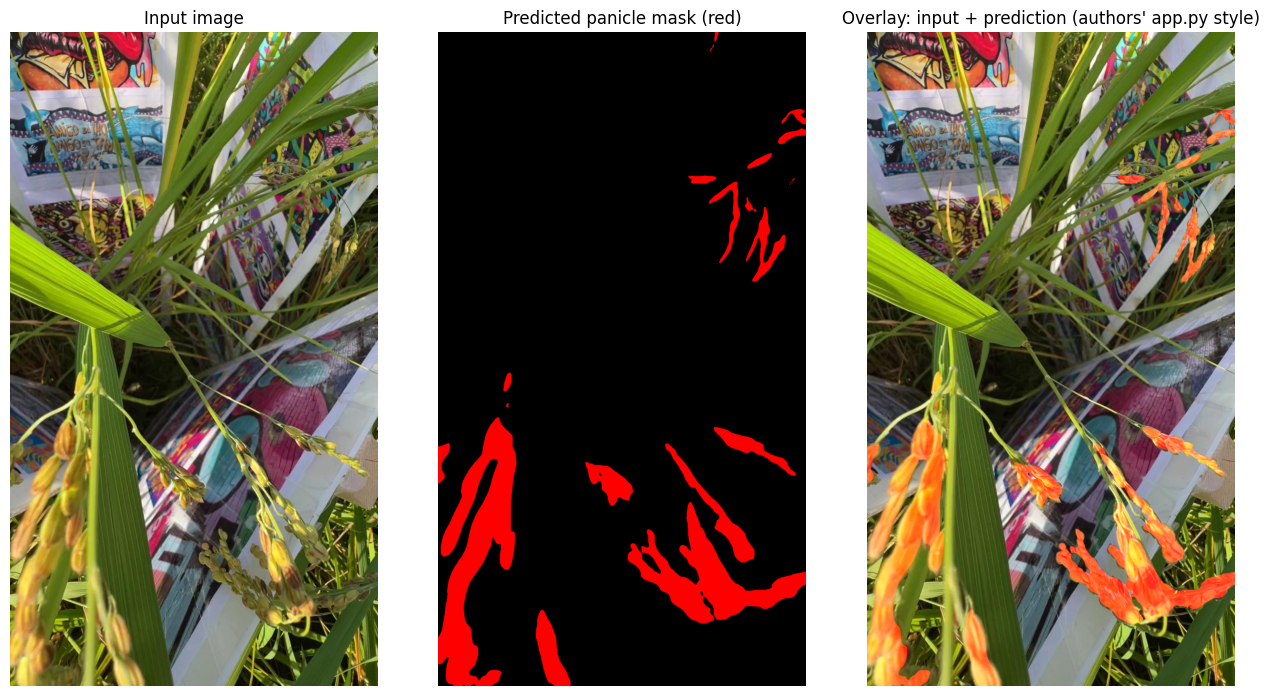

In [ ]:
import cv2, json
import matplotlib.pyplot as plt

img_bgr = cv2.imread("/content/cvrp/T42_1220.jpg")
pred_mask_bgr = cv2.imread("/content/cvrp/mask_pred.png")
pred_viz = cv2.imread("/content/cvrp/overlay_result.png")
stats = json.load(open("/content/cvrp/stats.json"))
print(f"Panicle pixels: {stats['panicle_fraction']*100:.2f} % of image | device: {stats['device']}")

fig, axes = plt.subplots(1, 3, figsize=(13, 7))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input image")
axes[1].imshow(cv2.cvtColor(pred_mask_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("Predicted panicle mask (red)")
axes[2].imshow(cv2.cvtColor(pred_viz, cv2.COLOR_BGR2RGB))
axes[2].set_title("Overlay: input + prediction (authors' app.py style)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/cvrp/overlay_fig.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Small results table and CSV export

**EN:** A minimal quantitative record of this single-image run: image/mask size, panicle class share, and device used. Exported as CSV inside Colab. This documents *this* run only; it is not a claim about the paper's validation metrics.

**JA:** 今回の単一画像実行の定量的な記録（画像サイズ・panicle 画素割合・使用デバイス）を表と CSV に保存します。

In [ ]:
import pandas as pd

stats = json.load(open("/content/cvrp/stats.json"))
img_bgr = cv2.imread("/content/cvrp/T42_1220.jpg")
df = pd.DataFrame([{
    "sample": "assets/T42_1220.jpg",
    "image_HxW": f"{img_bgr.shape[0]}x{img_bgr.shape[1]}",
    "mask_HxW": f"{stats['mask_H']}x{stats['mask_W']}",
    "panicle_pixel_fraction": round(stats["panicle_fraction"], 4),
    "device": stats["device"],
    "model": "Mask2Former.pth (CVRPDataset/Model)",
}])
display(df)
df.to_csv("/content/cvrp/cvrp_single_image_result.csv", index=False)
print("saved /content/cvrp/cvrp_single_image_result.csv")

,sample,image_HxW,mask_HxW,panicle_pixel_fraction,device,model
0,assets/T42_1220.jpg,1920x1080,1920x1080,0.0962,cuda:0,Mask2Former.pth (CVRPDataset/Model)


saved /content/cvrp/cvrp_single_image_result.csv


## 8. Interpretation and limitations

**EN:** The authors released `Mask2Former.pth` as their best panicle segmentation model (paper: Mask2Former achieved the best IoU of the four benchmarks, 73.38 on multicultivar images / 76.56 on field scenes — **not re-measured here**). Our run applies that released model to one of its own bundled sample images through the authors' own inference code path, so a panicle-focused red mask on plant structures is the expected qualitative outcome. Limitations: single image; no ground-truth annotation here to compute IoU against; the full CVRP dataset is gated on Hugging Face and was not used; environment adapted to torch 2.1.2 + mmcv 2.1.0 + mmsegmentation 1.2.2 in a Colab-internal Python 3.11 venv (model, weights, config, and inference logic unchanged).

**JA:** 論文で最良成績だった Mask2Former の公開重みを、著者自身の推論コード経由で同梱サンプル画像に適用しました。単一画像・IoU 未検証・データセット本体（gate 付き）は未使用である点に留意してください。

**References:** paper DOI 10.1016/j.plaphe.2025.100025; code/weights https://huggingface.co/CVRPDataset/Model (README pins mmsegmentation v1.1.2, mmcv 2.0.0); dataset (gated) https://huggingface.co/datasets/CVRPDataset/CVRP. Access date 2026-10-05.